# FITS 파일 열어보기

* 이 노트북을 구글 코랩에서 실행하고자 한다면 [파일] - [드라이브에 사본 저장]을 하여 본인의 소유로 만든 후에 코드를 실행하거나 수정할 수 있습니다.

* 이 파일은 실제 수업에 사용하므로 필요에 따라 예고 없이 변경될 수 있습니다.

* If you have any questions or comments on this document, please email me(Kiehyun.Park@gmail.com).

* 이 파일(문서)는 공교육 현장에서 수업시간에 자유롭게 사용할 수 있으나, 다른 목적으로 사용할 시에는 사전에 연락을 주셔서 상의해 주시기 바랍니다.

이 자료는 천체 관측 자료인 FITS 파일을 열어 관련 정보를 알아보는 방법을 설명합니다.

## 필요한 환경

이 프로젝트를 위해서는 아래의 모듈이 필요합니다.

> numpy, matplotlib, astropy, version_information


### 구글 코랩에 한글 폰트 설치

matplotlib에서 한글을 사용하기 위해서는 한글 폰트가 필요하다. 구글 코랩에서 현재의 Jupyter notebook을 실행한다면 아래 코드를 실행 한 후 런타임 다시 시작을 해 줘야 한글을 사용할 수 있을 것이다.

In [1]:
#!sudo apt-get install -y fonts-nanum
#!sudo fc-cache -fv
#!rm ~/.cache/matplotlib -rf

### 런타임 다시 시작

위의 셀을 실행한 다음 반드시 다음 과정을 잊지 말자.

* [메뉴]-[런타임]-[런터임 다시 시작]

* [메뉴]-[런타임]-[이전 셀 실행]을 해주어야 한다.

### 한글 폰트 사용

위에서 한글 폰트를 설치하고, 런타임 다시시작을 했다면 구글 코랩에서 폰트 경로를 설정하여 한글 사용이 가능해 진다.

In [2]:
#visualization
import matplotlib as mpl
import matplotlib.pylab as plb
import matplotlib.pyplot as plt

# 브라우저에서 바로 그려지도록
%matplotlib inline

# 그래프에 retina display 적용
%config InlineBackend.figure_format = 'retina'

# Colab 의 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')

# 유니코드에서  음수 부호설정
mpl.rc('axes', unicode_minus=False)

### 모듈 설치 및 버전 확인

아래 셀을 실행하면 이 노트북을 실행하는데 필요한 모듈을 설치하고 파이썬 및 관련 모듈의 버전을 확인할 수 있다.

In [3]:
import importlib, sys, subprocess
packages = "numpy, matplotlib, astropy, astroquery, version_information" # required modules
pkgs = packages.split(", ")
for pkg in pkgs :
    if not importlib.util.find_spec(pkg):
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f"**** {pkg} module is now installed.")
    else:
        print(f"******** {pkg} module is already installed.")
%load_ext version_information
import time
now = time.strftime("%Y-%m-%d %H:%M:%S (%Z = GMT%z)")
print(f"This notebook was generated at {now} ")

vv = %version_information {packages}
for i, pkg in enumerate(vv.packages):
    print(f"{i} {pkg[0]:10s} {pkg[1]:s}")

******** numpy module is already installed.
******** matplotlib module is already installed.
******** astropy module is already installed.
******** astroquery module is already installed.
******** version_information module is already installed.
This notebook was generated at 2023-09-17 16:22:16 (KST = GMT+0900) 
0 Python     3.11.4 64bit [GCC 11.2.0]
1 IPython    8.12.2
2 OS         Linux 5.15.0 83 generic x86_64 with glibc2.31
3 numpy      1.25.2
4 matplotlib 3.7.2
5 astropy    5.2.1
6 astroquery 0.4.6
7 version_information 1.0.4


## FITS 파일



## 데이터 저장

### FITS 파일 저장 폴더 생성

FITS 파일을 저장할 폴더를 "Comat_fits_files" 이라는 이름으로 생성해보자.

* 만약 리눅스 시스템 이라면 shell 명령어로 가능한데, "!"를 붙이면 shell 명령어를 실행할 수 있다.
> !mkdir Comat_fits_files

OS의 영향을 받지 않기 위하여 pathlib을 사용하여 폴더를 생성해 보자.

In [4]:
import os
from pathlib import Path
BASEPATH = Path("./")
save_dir_name = "Comat_fits_files"
print(f"BASEPATH: {BASEPATH}")

if not (BASEPATH/save_dir_name).exists():
    os.mkdir(str(BASEPATH/save_dir_name))
    print (f"{str(BASEPATH/save_dir_name)} is created...")
else :
    print (f"{str(BASEPATH/save_dir_name)} is already exist...")

BASEPATH: .
Comat_fits_files is already exist...


### FITS 파일 다운로드

나의 구글 드라이브에 저장된 CCD 관측 파일을 다운받아 보자.

GNU Wget은 HTTP 통신 또는 FTP 통신을 사용해 서버에서 파일 또는 콘텐츠를 다운로드할 때 사용하는 소프트웨어이다. Wget의 특징은 여러 파일을 한 번에 다운로드하거나 웹 페이지의 링크를 순회하며 여러 콘텐츠를 자동으로 다운로드할 때 매우 편리하다.

구글 코랩도 wget을을 지원해주니 아래 셀을 실행하면 자신의 [작업 영역]에 저장된다. 하지만 이 파일은 이 런타임이 재실행 될때는 삭제됨에 유의하자.

아래 코드를 실행하면 여러분의 작업영역에 해당 파일을 저장할 것이다.



In [5]:
fname = "46P-WIRTANEN_LIGHT_R_2018-12-13-17-46-15_60sec_FSQ106ED-x73_QSI683ws_-30c_2bin.fit"
fid = "1qJQdbmdeHg23sPdLKRGfPq93Sfo1HT_3"

# wget을 이용(나의 구굴드라이브에서 공유한 파일을 구글 코랩에서 사용할 경우)
!wget --no-check-certificate "https://docs.google.com/uc?export=download&id={fid}" -O {save_dir_name}/{fname}

# gdown을 이용(나의 구굴드라이브에서 공유한 파일을 다운로드)
#!gdown {fid} -O {save_dir_name}/{fname}

--2023-09-17 16:22:17--  https://docs.google.com/uc?export=download&id=1qJQdbmdeHg23sPdLKRGfPq93Sfo1HT_3
Resolving docs.google.com (docs.google.com)... 142.250.206.238, 2404:6800:4004:823::200e
Connecting to docs.google.com (docs.google.com)|142.250.206.238|:443... connected.
HTTP request sent, awaiting response... 

303 See Other
Location: https://doc-0g-6c-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/2980vv35u148negj8kt2qdu4mqlr8ufb/1694935275000/11752785994579589476/*/1qJQdbmdeHg23sPdLKRGfPq93Sfo1HT_3?e=download&uuid=fc88e000-462f-42f7-b2f4-9ff841b555c8 [following]
--2023-09-17 16:22:18--  https://doc-0g-6c-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/2980vv35u148negj8kt2qdu4mqlr8ufb/1694935275000/11752785994579589476/*/1qJQdbmdeHg23sPdLKRGfPq93Sfo1HT_3?e=download&uuid=fc88e000-462f-42f7-b2f4-9ff841b555c8
Resolving doc-0g-6c-docs.googleusercontent.com (doc-0g-6c-docs.googleusercontent.com)... 142.250.207.33, 2404:6800:400a:80e::2001
Connecting to doc-0g-6c-docs.googleusercontent.com (doc-0g-6c-docs.googleusercontent.com)|142.250.207.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4173120 (4.0M) [application/octet-stream]
Saving to: ‘Comat_fits_files/46P-WIRTANEN_LIGHT_R_2018-12-13-17-46-15_60sec_FSQ106ED-x73_Q

### 다운로드한 파일 확인

만약 구글 코랩을 사용한다면 오른쪽의 [파일]창에서 확인할 수 있다.

다음의 코드를 실행하면 해당 파일을 확인해 볼 수 있다.

In [6]:
from pathlib import Path
fpaths = sorted(list((BASEPATH/save_dir_name).glob('*')))
print(f"fpaths: {fpaths}")
print(f"len(fpaths): {len(fpaths)}")

fpaths: [PosixPath('Comat_fits_files/46P-WIRTANEN_LIGHT_R_2018-12-13-17-46-15_60sec_FSQ106ED-x73_QSI683ws_-30c_2bin.fit')]
len(fpaths): 1


##  FITS handling

### Read file



In [7]:
from astropy.io import fits
hdul = fits.open(str(fpaths[0]))

print("type(hdul) :", type(hdul))
print("hdul :", hdul)

type(hdul) : <class 'astropy.io.fits.hdu.hdulist.HDUList'>
hdul : [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x7f20efb10a90>]


HDUList 이므로 그 길이를 알아보자.

In [8]:
print("len(hdul) :", len(hdul))

len(hdul) : 1


dir 함수를 이용하여 객체에 사용할수 있는 mathod를 알아보자.

In [9]:
print("dir(hdul) :", dir(hdul))
print("dir(hdul[0]) :", dir(hdul[0]))

dir(hdul) : ['__add__', '__class__', '__class_getitem__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__doc__', '__enter__', '__eq__', '__exit__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__imul__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__mul__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__rmul__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_data', '_file', '_flush_resize', '_flush_update', '_in_read_next_hdu', '_open_kwargs', '_positive_index_of', '_read_all', '_read_next_hdu', '_readfrom', '_resize', '_truncate', '_try_while_unread_hdus', '_verify', '_wasresized', 'append', 'clear', 'close', 'copy', 'count', 'extend', 'fileinfo', 'filename', 'flush', 'fromfile', 'fromstring', 'index', 'index_of', 'info', 'insert', 'pop', 'rea

### header

In [10]:
print("type(hdul[0].hedaer) :", type(hdul[0].header))
#print("hdul[0].hedaer :", hdul[0].header)
hdul[0].header

type(hdul[0].hedaer) : <class 'astropy.io.fits.header.Header'>


SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                   16 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                 1663 / length of data axis 1                          
NAXIS2  =                 1252 / length of data axis 2                          
EXTEND  =                    T / FITS dataset may contain extensions            
BSCALE  =                    1 / default scaling factor                         
BZERO   =                32768 / offset data range to that of unsigned short    
PROGRAM = 'PixInsight 1.8.8-7' / Software that created this HDU                 
COLORSPC= 'Grayscale'          / PCL: Color space                               
RESOLUTN=                  72. / PCL: Resolution in pixels per resolution unit  
RESOUNIT= 'inch    '           / PCL: Resolution unit                           
THUMBIMG= 'Thumbnail'       

header는 key와 value가 들어 있다.

In [11]:
print("hdul[0].hedaer['DATE-OBS'] :", hdul[0].header['DATE-OBS'])
print("type(hdul[0].hedaer['DATE-OBS']) :", type(hdul[0].header['DATE-OBS']))

hdul[0].hedaer['DATE-OBS'] : 2018-12-13T17:46:15.000
type(hdul[0].hedaer['DATE-OBS']) : <class 'str'>


### data

관측 자료는 numpy.ndarray 형태로 들어 있음을 알 수 있다.

In [12]:
print("type(hdul[0].data) :", type(hdul[0].data))
print("hdul[0].data.dtype :", hdul[0].data.dtype)
print("hdul[0].data :", hdul[0].data)

type(hdul[0].data) : <class 'numpy.ndarray'>
hdul[0].data.dtype : uint16
hdul[0].data : [[33368 34170 33854 ... 36466 36010 36280]
 [33296 33358 33634 ... 36270 36458 36298]
 [33778 33790 33436 ... 36250 36342 36420]
 ...
 [33136 32798 32880 ... 34380 34958 35132]
 [33104 33602 33616 ... 34602 35266 34674]
 [32786 33022 32562 ... 35194 34450 35042]]


### Display image

matplotlib을 이용하면 numpy.ndarray를 화면에 디스플레이할 수 있습니다.

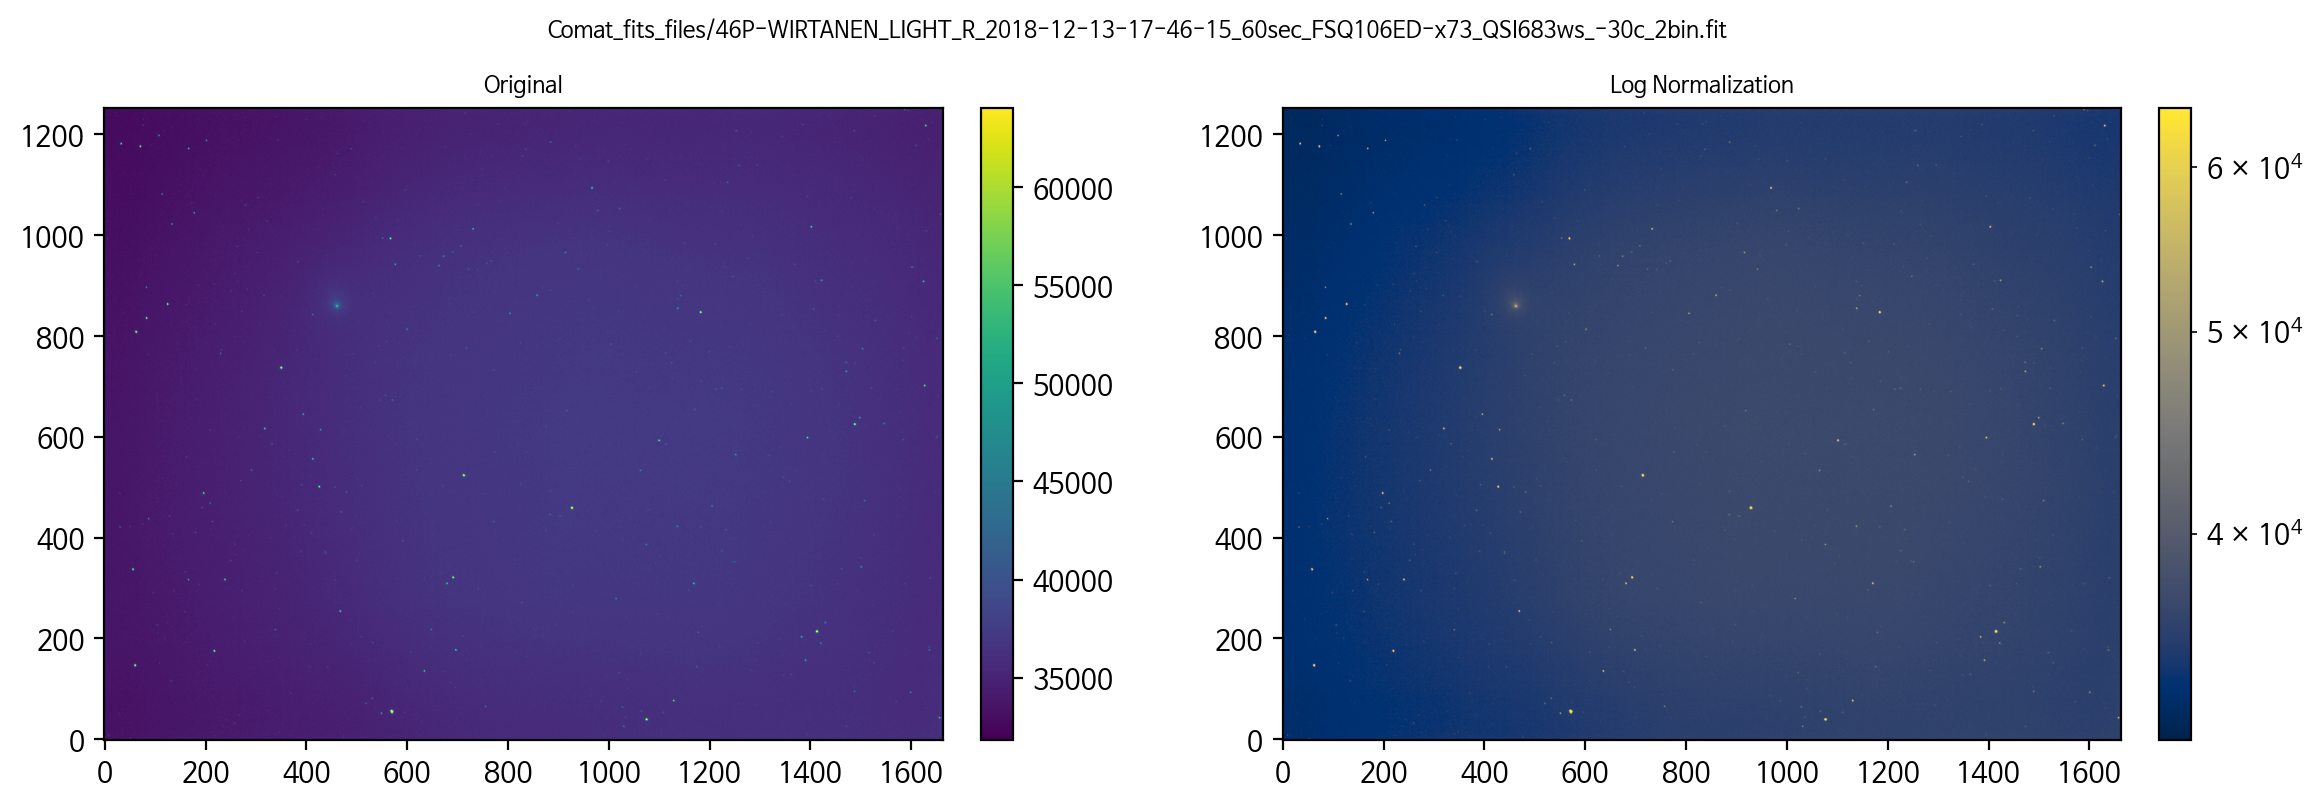

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, NoNorm

fig, axs = plt.subplots(1, 2, figsize=(12, 4),
                       sharex=False, sharey=False, gridspec_kw=None)
im1 = axs[0].imshow(hdul[0].data,
                origin='lower',
                #norm=LogNorm(),
                #cmap='cividis',
                )
axs[0].set_title('Original', fontsize=8)

im2 = axs[1].imshow(hdul[0].data,
                origin='lower',
                norm=LogNorm(),
                cmap='cividis',
                )
axs[1].set_title('Log Normalization', fontsize=8)

fig.suptitle(f'{str(fpaths[0])}', fontsize=8)
fig.colorbar(im1, ax = axs[0], fraction=0.035, pad=0.04)
fig.colorbar(im2, ax = axs[1], fraction=0.035, pad=0.04)
plt.tight_layout()

## plage solving




### astrometry solving




In [14]:
from astroquery.astrometry_net import AstrometryNet

ast = AstrometryNet()
ast.api_key = 'bldvwzzuvktnwfph'

try_again = True
submission_id = None
solve_timeout = 300

while try_again:
    try:
        if not submission_id:
            wcs_header = ast.solve_from_image(str(fpaths[0]), 
                                force_image_upload=True,
                                solve_timeout = solve_timeout,
                                submission_id=submission_id)
        else:
            wcs_header = ast.monitor_submission(submission_id,
                                                solve_timeout=solve_timeout)
    except TimeoutError as e:
        submission_id = e.args[1]
    else:
        # got a result, so terminate
        try_again = False

if wcs_header:
    # Code to execute when solve succeeds
    print("fits file solved successfully...")
else:
    # Code to execute when solve fails
    print("fits file solving failure...")

JSONDecodeError: Expecting value: line 2 column 1 (char 1)

자료 형태를 보면 리스트, 리스트, 리스트의 형태임을 알수 있다. 어떻게 인덱싱 할 수 있는가?

In [ ]:
print("sun_circle: ", sun_circle)
print("sun_circle[0]: ", sun_circle[0])
print("sun_circle[0][0]: ", sun_circle[0][0])

3차원의 자료로 본다면 아래와 같이 간단하게 인덱싱할 수도 있다.

In [ ]:
print("sun_circle[0, 0, :]: ", sun_circle[0, 0, :])

픽셀 주소는 정수로 반올림을 하고, 인덱싱하기 좋도록 1차원의 리스트로 만들어 주자.

In [ ]:
# convert the (x, y, r) coordinates and radius of the circles to integers
sun_circle = np.round(sun_circle[0,0,:]).astype(int)
print('circle of sun', sun_circle )

이 과정은 경우에 따라 실패할 수도 있으며, 실패할 경우 이미지의 중심인 [512, 512, 480] 정도로 사용해도 될 것이다.

### 원 그리기

태양 이미지 위에 원을 그려보자.

[matplotlib.patches.Circle](https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Circle.html) 함수를 이용하면 원을 그릴 수 있다.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(sun_im,
           cmap = 'gray',
           origin='upper',
           interpolation = 'None')

# Drawing circle on the sun image
circle = Circle((sun_circle[0], sun_circle[1]), sun_circle[2],
                facecolor='none',
                edgecolor=(0, 0.8, 0.8), linewidth=2, alpha=0.5)

ax.add_patch(circle)

plt.show()

## 흑점(어두운 픽셀) 찾아내기

태양 이미지에서 흑점은 어떻게 찾을 수 있을까?

일단 픽셀값을 읽어 어두운 픽셀일 경우에 흑점일 가능성이 높을 것이다. 그렇다면 검은색을 찾아내는 간단한 알고리즘으로 흑점을 찾아보자.

태양의 사진을 보면 흑점도 검은색이고, 배경도 검은색이다. 이러한 처리를 하기 위해 먼저 태양사진 원본으로 부터 sun_im_output 이라는 변수로 복사해 보자.

In [ ]:
# copy image for processing
sun_im_output = sun_im.copy()
print("sun_im_output: ", sun_im_output)

### 배경 선택 array

검은색 배경은 흑점 판단에 방해가 되므로 배경이 되는 부분을 삭제하기위한 masking array를 생성하고자 한다. 주연감광으로 인해 어두워진 가장자리 일부는 흑점 판단에 어려움을 초래하므로 그 경계부분을 잘 결정해야 한다. 여기에서 boundary_width는 위에서 구한 원의 방정식에서 주연감광으로 어두워진 픽셀들을 제외하기 위한 변수이다.

* outer : 이미지의 가장자리 영역으로 흑점 판단에 방해가 될 것으로 생각되어 흑점 판단에서 제외할 부분의 bool array

* inner : 가장자리 영역을 제외하고, 흑점이 있는지 판단할 중심 부분의 bool array

In [ ]:
# make masking array for background
X, Y = np.ogrid[0:im_width, 0:im_height]

# 경계 두께 설정
boundary_width = 40 # variable for removing limb darkening area

# 마스킹 bool array  설정
outer = (X - sun_circle[0]) ** 2 + (Y - sun_circle[1]) ** 2 > (sun_circle[2] - boundary_width) ** 2
inner = (X - sun_circle[0]) ** 2 + (Y - sun_circle[1]) ** 2 < (sun_circle[2] - boundary_width) ** 2

print ("type(outer): ", type(outer))
print ("type(inner):", type(inner))

array shape을 확인해 보고, 그 값을 출력해 보자.

In [ ]:
print (np.shape(outer), np.shape(inner))

print ("outer:", outer)
print ("inner", inner)

### 배경 영역 흰색으로 바꾸기

아래와 같은 코드로 경계선 바깥 영역을 모두 흰색으로 바꿀 수 있다.

In [ ]:
# 8 bit image에서 흰색은 255이다.
sun_im_output[outer] = 255

우리가 흑점을 판단할 부분만 남긴 사진을 보면 다음과 같다.

원에서 boundary width 만큼 안쪽으로 흰색으로 바꿔 버렸다. 이렇게 하면 아쉽지만 boundary width에 해당하는 태양의 가장자리 부분의 흑점은 찾을 수 없게 된다.

In [ ]:
print ('boundary width :', boundary_width)

fig, ax = plt.subplots()

# 이미지 나타내기
plt.imshow(sun_im_output,
           cmap = 'gray',
           origin='upper',
           interpolation = 'None')

# 원 그리기
circle = Circle((sun_circle[0], sun_circle[1]), sun_circle[2],
                facecolor='none',
                edgecolor=(0, 0.8, 0.8), linewidth=2, alpha=0.5)
ax.add_patch(circle)

plt.show()

### 흑점(어두운 픽셀)의 값 설정

흑점이라고 생각되는 픽셀 만을 골라보자. 흑점 판단 기준을 bright_criterion 변수를 사용하여 70보다 어두운 부분을 흑점인 픽셀로 분류해 보았다.

먼저 태양사진과 같은 크기의 masking array 를 만들어 보자.

In [ ]:
# Obtaining pixels expected to be sunspots

# variable for sunspot criterion
bright_criterion = 70

# 흑점 픽셀에 대한 masking array 만들기
sunspot_mask  = np.zeros((im_width, im_height)).astype(bool)

### 흑점(어두운 픽셀) 모으기

흑점이라고 생각되는 픽셀의 좌표와 픽셀값을 check_pixel 변수에 list 형태로 저장해 보자.

In [ ]:
check_pixel = [] # x, y, intensity
for i in range(0, im_width):
    for j in range(0, im_height):
        if(sun_im_output[i,j] < bright_criterion):
            sunspot_mask[i,j] = 0
            check_pixel.append([j, i, sun_im_output[i,j]])
        else :
            sunspot_mask[i,j] = 1

print("len(check_pixel): ", len(check_pixel))
print("check_pixel: ", check_pixel)

흑점이 아니라고 생각되는 픽셀을 흰색인 255로 변경해 보자.

In [ ]:
#non-sunspot pixels will be white
sun_im_output[sunspot_mask] = 255
print("sun_im_output: ", sun_im_output)

### 흑점(어두운 픽셀) plotting

흑점으로 예상되는 픽셀들만 표출해 보자.

In [ ]:
fig, ax = plt.subplots()

# 이미지 나타내기
plt.imshow(sun_im_output,
           cmap = 'gray',
           origin='upper',
           interpolation = 'None')

#원 그리기
circle = Circle((sun_circle[0], sun_circle[1]), sun_circle[2],
                facecolor='none',
                edgecolor=(0, 0.8, 0.8), linewidth=2, alpha=0.5)
ax.add_patch(circle)

# to hide tick values on X and Y axis
#plt.xticks([]), plt.yticks([])
plt.show()

## 흑점 갯수 구하기

### 픽셀 그룹화

 check_pixel 변수에 저장되어 있는 흑점 픽셀들을 그룹화 해보자.

 먼저 리스트 형태의 check_pixel을 2차원 배열로 만들어 보자.

In [ ]:
check_pixel = np.asarray(check_pixel)
print("check_pixel:", check_pixel)

### 픽셀 plotting

이번에는 어두운 픽셀들을 화면에 polt 해 보자.

이 부분은 현재까지 처리 과정에 오류가 없는지 확인할 수 있게 해 줄 것이다.

In [ ]:
print ('number of pixels for  for checking if it is sunspot or not :', len(check_pixel))

#print (check_pixel)
if len(check_pixel) == 0 :
    print('There is no sunspot pixel in the image')
else :
    fig,ax = plt.subplots()

    l = plt.plot(check_pixel[:,0],
                 (im_height-check_pixel[:,1]),
                 'bo',
                 markersize=2)

    # 원 그리기
    circle = Circle((sun_circle[0], sun_circle[1]), sun_circle[2],
                    facecolor='none',
                    edgecolor=(0, 0.8, 0.8), linewidth=3, alpha=0.5)
    ax.add_patch(circle)

    # to hide tick values on X and Y axis
    #plt.xticks([]), plt.yticks([])

    plt.show()

### 흑점 픽셀 데이터 만들기

chekc_pixel에 들어있는 픽셀 좌표만 1인 masking array 를 만들어 보자.

In [ ]:
# make list for checking pixels
image = [[0 for a in range(im_width)] for b in range(im_height)]

# convert array
image = np.array(image)

# 흑점(어두운 픽셀) 좌표를 1로 변환
for i in check_pixel:
    image[i[0], i[1]] = 1

print("type(image): ", type(image))

image를 plotting 해 보자.

In [ ]:
fig, ax = plt.subplots()

# 이미지 나타내기
plt.imshow(image,
           cmap = 'gray',
           origin='upper',
           interpolation = 'None')

#원 그리기
circle = Circle((sun_circle[0], sun_circle[1]), sun_circle[2],
                facecolor='none',
                edgecolor=(0, 0.8, 0.8), linewidth=2, alpha=0.5)
ax.add_patch(circle)

# to hide tick values on X and Y axis
#plt.xticks([]), plt.yticks([])

plt.show()

뭔가 이상하다, 픽셀 주소와 matplotlib의 가로축, 세로축이 반대여서 생기는 문제인것 같다.

image는 array 이므로 image.T 메서드로 전차행렬을 구해서 간단히 해결할 수 있다.

In [ ]:
fig, ax = plt.subplots()

# 이미지 나타내기
plt.imshow(image.T,
           cmap = 'gray',
           interpolation = 'None')

#원 그리기
circle = Circle((sun_circle[0], sun_circle[1]), sun_circle[2],
                facecolor='none',
                edgecolor=(0, 0.8, 0.8), linewidth=2, alpha=0.5)
ax.add_patch(circle)

# to hide tick values on X and Y axis
#plt.xticks([]), plt.yticks([])

plt.show()

### 흑점 좌표의 위도, 경도 구하기

흑점의 x, y 좌표로 부터 위도와 경도를 구하는 함수이다. 이 과정에서 앞에서 알아낸 원의 방정식을 이용하였다.


In [ ]:
# Calculation of latitude and longitude of sunspot on sun
def latitude(y):
    return math.asin( (sun_circle[1] - y) / sun_circle[2] )

def longitude(x, y):
    return math.asin( (x - sun_circle[0]) / (sun_circle[2] * math.cos(latitude(y))) )

### DFS algorithm

[DFS algorithm](https://en.wikipedia.org/wiki/Depth-first_search) 깊이 우선 탐색 알고리즘이다.

또한 check_pixel 변수에 저장되어 있는 pixel들로 흑점을 판단하기 위해 DFS algorithm 을 적용하는 함수이다.

In [ ]:
#######################################################
#### DFS range. Need to determine this taxi radius.####
dx = [0, 1, 1, 1, 0, -1, -1, -1]
dy = [1, 1, 0, -1, -1, -1, 0, 1]
#######################################################
def dfs(x, y): # DFS(Depth First Search)
    global x_pixel_sum
    global y_pixel_sum
    global num_pixel
    image[x][y] = -1 # mark as already visited.
    x_pixel_sum += x
    y_pixel_sum += y

    num_pixel += 1
    for i in range(0,len(dx)):
        if(image[x+dx[i]][y+dy[i]] == 1):
            dfs(x+dx[i],y+dy[i])
#######################################################

check_pixel 변수에 저장되어 있는 pixel들이 2개 이상 인접해 있으면 흑점으로 판단하도록 DFS 알고리즘을 적용하였다.

In [ ]:
# identify sunspot from check_pixel
pixel_num_criterion = 2

#x_average, y_average, num_pixel
sunspot_data = []

for a in range(0,im_width):
    for b in range(0,im_height):
        if(image[a][b] == 1):
            x_pixel_sum = 0
            y_pixel_sum = 0
            num_pixel = 0
            print('DFS...', a, b)
            dfs(a,b)
            if num_pixel > pixel_num_criterion :
                x_average = x_pixel_sum / num_pixel
                y_average = y_pixel_sum / num_pixel
                latit = latitude(y_average)
                longi = longitude(x_average, y_average)
                latit = math.degrees(latit)
                longi = math.degrees(longi)
                #sunspot_data.append([longi, latit, num_pixel])
                sunspot_data.append([int(x_average), int(y_average), num_pixel])
print ('*'*80)
print ('number of sunspot : ', len(sunspot_data))
print ('sunspot data : ', sunspot_data) #x, y, num_pixel

### 태양 이미지 위에 흑점 표현하기

흑점의 좌표를 표시하기 위하여  먼저 흑점의 좌표를 array로 변환하자.

In [ ]:
sunspot_data = np.asarray(sunspot_data)
print("sunspot_data:\n", sunspot_data)

다음과 같이 태양 사진 위에 흑점의 좌표를 표시한다.

In [ ]:
if len(sunspot_data) == 0 :
    print('There is no sunspot in the image')
else :
    fig,ax = plt.subplots()
    # load the sun image
    plt.imshow(sun_im,
               cmap = 'gray',
               interpolation = 'None')

    # draw a circle
    circle = Circle((sun_circle[0], sun_circle[1]), sun_circle[2],
                    facecolor='none',
                    edgecolor=(0, 0.8, 0.8), linewidth=3, alpha=0.5)
    ax.add_patch(circle)

    # plot sunspot
    plt.plot(sunspot_data[:,0],
             (sunspot_data[:,1]),
             'ro',
             markersize=3)

    plt.show()

### 이미지 저장

완료된 이미지를 저장하기 위한 코드를 추가하면 쉽게 저장할 수 있다.

In [ ]:
if len(sunspot_data) == 0 :
    print('There is no sunspot in the image')
else :
    fig,ax = plt.subplots()
    # load the sun image
    plt.imshow(sun_im,
               cmap = 'gray',
               interpolation = 'None')

    # draw a circle
    circle = Circle((sun_circle[0], sun_circle[1]), sun_circle[2],
                    facecolor='none',
                    edgecolor=(0, 0.8, 0.8), linewidth=3, alpha=0.5)
    ax.add_patch(circle)

    # plot sunspot
    plt.plot(sunspot_data[:,0],
             (sunspot_data[:,1]),
             'ro',
             markersize=3)

    # savefig
    plt.savefig(f'{str(fpaths[0].parents[0])}/{fpaths[0].stem}.png')

    print(f'{str(fpaths[0].parents[0])}/{fpaths[0].stem}.png is created...')
    plt.show()

##(과제)

다음에 해당하는 SDO 자료를 받아 위의 프로세스를 수행해 보세요.

* 일시: 2018년 자신의 생일날 정오(KST) 무렵

* SDO 자료 중 1024 pixel의 HMII


In [ ]:
#(과제) 아래 코딩을 완성하여 제출하시오.





